In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

MODEL_PATH = './model/pothole_detection_model.h5'
TEST_DIR = './dataset/test'  
EXTERNAL_TEST_DIR = './testing' 
OUTPUT_DIR = './prediction_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries loaded and paths defined.")

Libraries loaded and paths defined.


In [2]:
try:
    model = load_model(MODEL_PATH)
except Exception as e:
    print(f"Error loading model: {e}")
    raise e

In [3]:
def convert_to_rgb(img_array):
    """Helper to ensure image is RGB."""
    if img_array.shape[-1] == 4:  
        return img_array[..., :3]
    return img_array

def predict_and_save_image(image_path, save_dir):

    try:
        filename = os.path.basename(image_path)
        
        # Load and preprocess image
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = convert_to_rgb(img_array)
        img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))
        
        # Predict
        prediction = model.predict(img_preprocessed)[0][0]
        status = "POTHOLE" if prediction > 0.5 else "NORMAL"
        confidence = prediction * 100 if prediction > 0.5 else (1 - prediction) * 100
        
        # Plot and Save
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {status} ({confidence:.2f}% confidence)")
        
        # Save plot
        save_path = os.path.join(save_dir, f"checked_{filename}")
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()
        print(f"Saved prediction for {filename} to {save_path}")
        plt.close()
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")

Processing external test images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


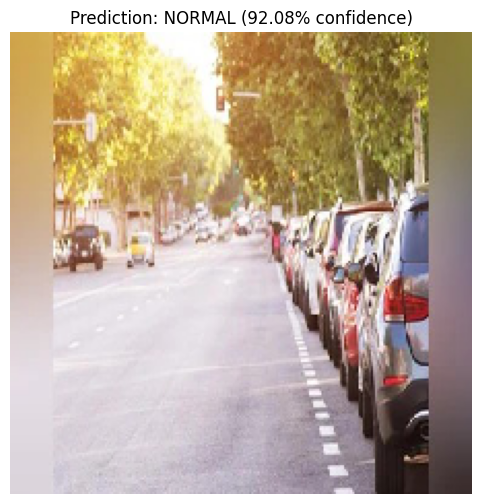

Saved prediction for Plain_Test_1.jpg to ./prediction_outputs\checked_Plain_Test_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


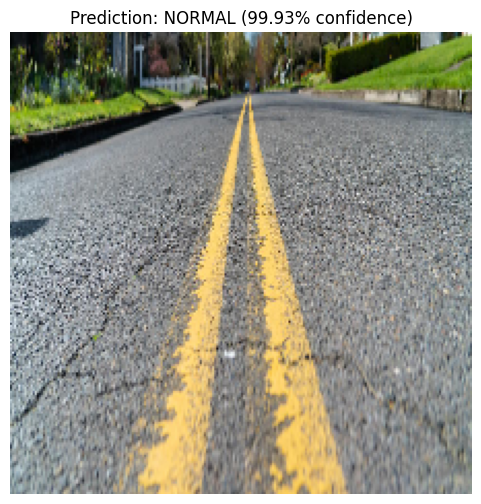

Saved prediction for Plain_Test_2.jpg to ./prediction_outputs\checked_Plain_Test_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


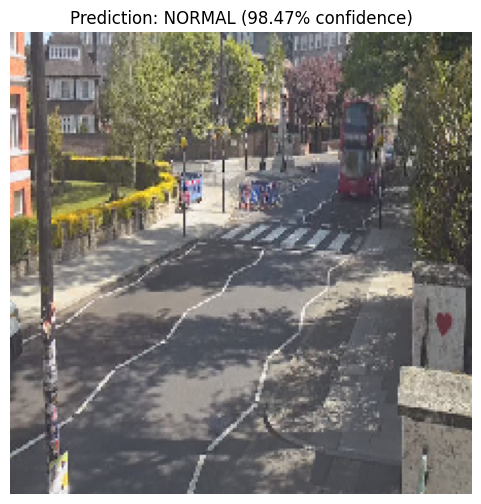

Saved prediction for Plain_Test_3.jpg to ./prediction_outputs\checked_Plain_Test_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


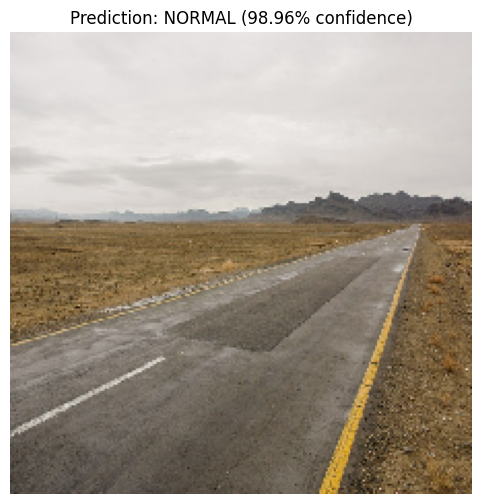

Saved prediction for Plain_Test_4.jpg to ./prediction_outputs\checked_Plain_Test_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


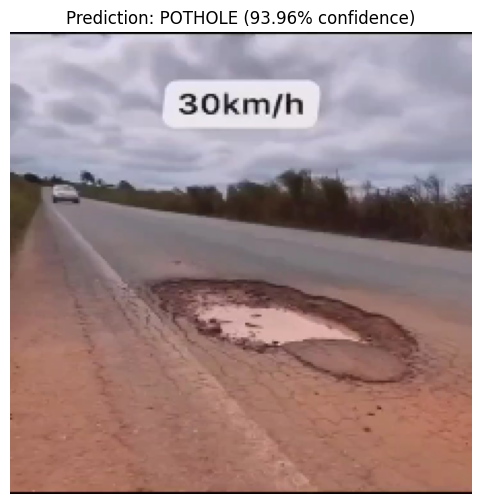

Saved prediction for Pothole_Test_1.jpg to ./prediction_outputs\checked_Pothole_Test_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


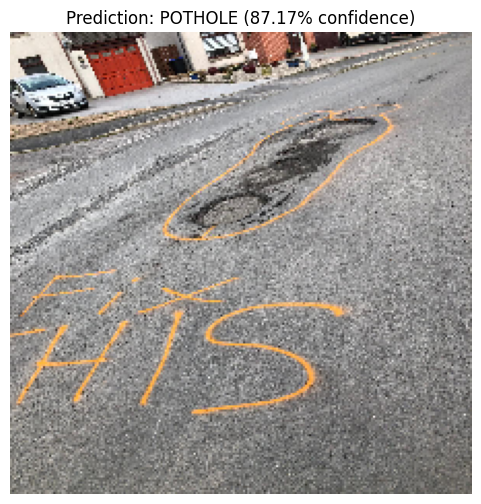

Saved prediction for Pothole_Test_2.jpg to ./prediction_outputs\checked_Pothole_Test_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


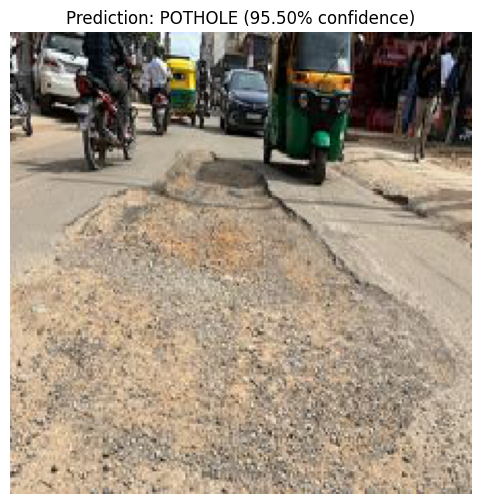

Saved prediction for Pothole_Test_3.jpg to ./prediction_outputs\checked_Pothole_Test_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


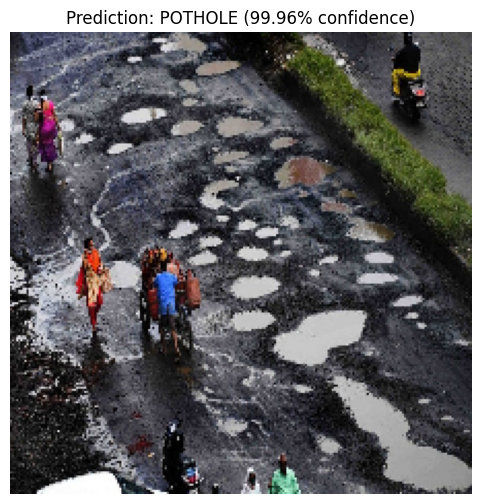

Saved prediction for Pothole_Test_4.jpg to ./prediction_outputs\checked_Pothole_Test_4.jpg


In [4]:
# Run prediction on specific external images
print("Processing external test images...")

if os.path.exists(EXTERNAL_TEST_DIR):
    for filename in os.listdir(EXTERNAL_TEST_DIR):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            
            image_path = os.path.join(EXTERNAL_TEST_DIR, filename)
            predict_and_save_image(image_path, OUTPUT_DIR)
else:
    print(f"External test directory {EXTERNAL_TEST_DIR} not found.")

Found 110 images belonging to 2 classes.
Evaluating on test dataset...
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9727 - loss: 0.0536
Test Accuracy: 97.27%
Test Loss: 0.0536
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


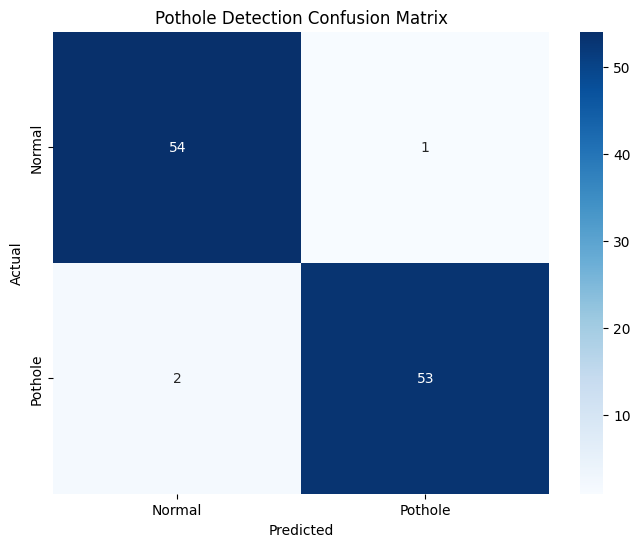

Confusion matrix saved to ./prediction_outputs\confusion_matrix.png
Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97        55
     Pothole       0.98      0.96      0.97        55

    accuracy                           0.97       110
   macro avg       0.97      0.97      0.97       110
weighted avg       0.97      0.97      0.97       110



In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def resnet_prep(img_array):
    return preprocess_input(img_array)

# Setup test generator for evaluation
# Assuming dataset structure: ./dataset/test/Normal and ./dataset/test/Pothole
if os.path.exists(TEST_DIR):
    test_datagen = ImageDataGenerator(preprocessing_function=resnet_prep)

    try:
        test_generator = test_datagen.flow_from_directory(
            TEST_DIR,
            target_size=(224, 224),
            batch_size=32,
            class_mode='binary',
            shuffle=False
        )
        
        # Evaluate
        print("Evaluating on test dataset...")
        evaluation = model.evaluate(test_generator)
        print(f"Test Accuracy: {evaluation[1]*100:.2f}%")
        print(f"Test Loss: {evaluation[0]:.4f}")
        
        # Generate Predictions
        y_pred_prob = model.predict(test_generator)
        y_pred = (y_pred_prob > 0.5).astype(int)
        y_true = test_generator.classes

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Normal', 'Pothole'], 
                    yticklabels=['Normal', 'Pothole'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Pothole Detection Confusion Matrix')
        
        # Save confusion matrix
        cm_save_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
        plt.savefig(cm_save_path)
        plt.show()
        print(f"Confusion matrix saved to {cm_save_path}")
        
        # Classification Report
        report = classification_report(y_true, y_pred, target_names=['Normal', 'Pothole'])
        print("Classification Report:")
        print(report)
        
        # Save report to text file
        with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
            f.write(report)
            
    except Exception as e:
        print(f"Error during evaluation: {e}")
else:
    print(f"Test dataset directory {TEST_DIR} not found. Skipping dataset evaluation.")